## Fragment Length Frequency + Rescaling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from random import shuffle

In [5]:
query_lengths = []
length_to_lines = {}

with open("query.bed", "r") as f:
    for line in f:
        fields = line.strip().split('\t')
        start, end = int(fields[1]), int(fields[2])
        length = end - start
        if length > 0:
            query_lengths.append(length)
            if length not in length_to_lines:
                length_to_lines[length] = []
            length_to_lines[length].append(line)
from collections import Counter
query_counts = Counter(query_lengths)
total_count = sum(query_counts.values())
norm_freq = {k: v / total_count for k, v in query_counts.items()}

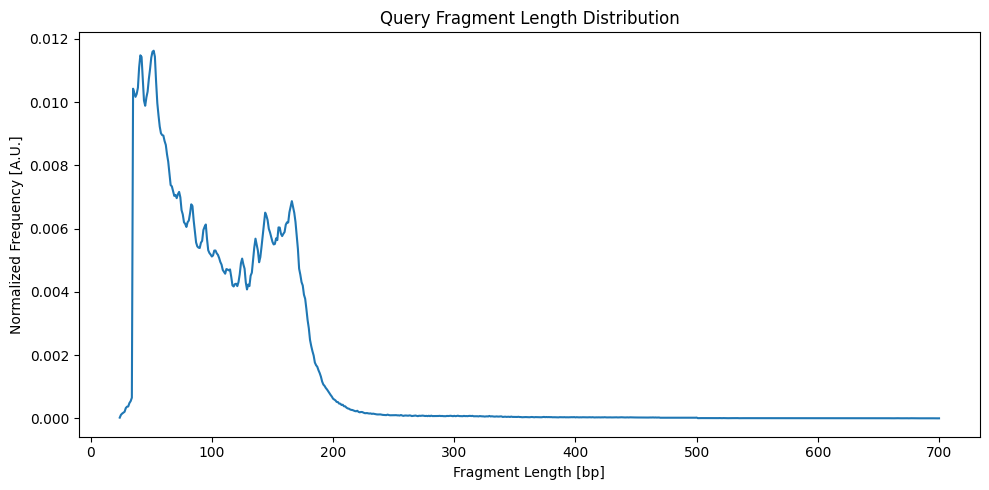

In [6]:
x = sorted(norm_freq.keys())
y = [norm_freq[k] for k in x]
plt.figure(figsize=(10, 5))
plt.plot(x, y)
plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Query Fragment Length Distribution")
plt.tight_layout()
plt.show()

In [7]:
ref_counts = {}
with open("reference.hist", "r") as f:
    for line in f:
        if line.strip():
            k, v = map(float, line.strip().split())
            ref_counts[int(k)] = v

total_ref = sum(ref_counts.values())
ref_freq = {k: v / total_ref for k, v in ref_counts.items()}


In [8]:
# Subsample query to align with reference distribution using preloaded lines
adjusted_records = []

for size, ref_prob in ref_freq.items():
    if size in length_to_lines:
        entries = length_to_lines[size]
        shuffle(entries)
        count = int(ref_prob * len(query_lengths))
        adjusted_records.extend(entries[:count])

# Recalculate frequencies after rescaling
rescaled_lengths = [int(line.split('\t')[2]) - int(line.split('\t')[1]) for line in adjusted_records]
rescaled_count = Counter(rescaled_lengths)
rescaled_total = sum(rescaled_count.values())
rescaled_freq = {k: v / rescaled_total for k, v in rescaled_count.items()}


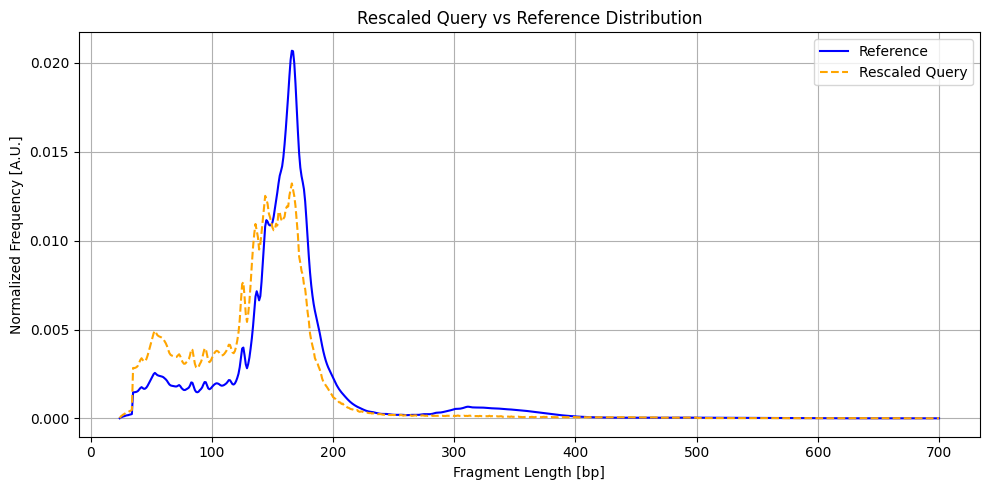

In [9]:
ref_x = sorted(ref_freq.keys())
ref_y = [ref_freq.get(k, 0) for k in ref_x]
rescaled_y = [rescaled_freq.get(k, 0) for k in ref_x]

plt.figure(figsize=(10, 5))
plt.plot(ref_x, ref_y, label="Reference", color='blue')
plt.plot(ref_x, rescaled_y, label="Rescaled Query", color='orange', linestyle='--')
plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Rescaled Query vs Reference Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
